# 16: Before There Are Messages

A received bit can causally change a receiver. The sender-specific signalling interpretation does not survive the control ladder.


In [1]:
from pathlib import Path
import json
import math
import random
import sys
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "notebooks" / "_shared"))

from digital_crystal import (
    CrystalParams, CrystalState, neighbors, hex_distance, hex_capacity,
    axial_to_xy, logistic, local_exposure_angle, initial_state, clone_state,
    morphology_hash, frontier, attachment_probability, advance_one_step,
    run_crystal, cell_keyed_uniform,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

NOTEBOOK_PROFILE = "quick"
RUN_CANONICAL = False

def load_json(path):
    return json.loads((ROOT / path).read_text(encoding="utf-8"))

def audit(expected, observed, source):
    return {
        "source": source,
        "expected": expected,
        "observed": observed,
        "matches": {k: observed.get(k) == v for k, v in expected.items()},
    }

def plot_cells(cells, title, ax=None, color="tab:blue"):
    ax = ax or plt.gca()
    pts = np.array([axial_to_xy(c) for c in cells]) if cells else np.empty((0, 2))
    if len(pts):
        ax.scatter(pts[:, 0], pts[:, 1], marker="h", s=42, c=color, alpha=0.9)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax


In [2]:
EXPERIMENT = {"radius": 56, "guard": 0.85, "message_gain": 0.65, "quick_horizon": 10}
{"maximum_cells": hex_capacity(EXPERIMENT["radius"]), "guard_cells": int(hex_capacity(EXPERIMENT["radius"]) * EXPERIMENT["guard"])}


{'maximum_cells': 9577, 'guard_cells': 8140}

## One-bit intervention as a checkpoint counterfactual


In [3]:
base_signal = np.full(24, 0.4)
checkpoint = run_crystal(base_signal[:12], seed=31, max_radius=28)
pulse = clone_state(checkpoint); no_pulse = clone_state(checkpoint)
for i in range(EXPERIMENT["quick_horizon"]):
    pulse_value = 1.0 if i == 0 else 0.4
    pulse, _ = advance_one_step(pulse, pulse_value + EXPERIMENT["message_gain"] * (i == 0), 28)
    no_pulse, _ = advance_one_step(no_pulse, 0.4, 28)
quick = {"symdiff": len(pulse.occupied ^ no_pulse.occupied), "pulse_pop": len(pulse.occupied), "no_pulse_pop": len(no_pulse.occupied)}
quick


{'symdiff': 125, 'pulse_pop': 717, 'no_pulse_pop': 702}

## Canonical artifact audit: causal transmission and controls


In [4]:
summary = load_json("research/digital-life/ch16-reports/ch16-summary.json")
single = load_json("research/digital-life/ch16-reports/stage-02-single-bit-intervention.json")
controls = load_json("research/digital-life/ch16-reports/stage-03-message-controls.json")
chain = load_json("research/digital-life/ch16-reports/stage-05-chain.json")
board = load_json("research/digital-life/ch16-reports/stage-06-crystal-board.json")
observed = {
    "single_bit_replicates": single["replicates"],
    "fraction_changed": round(summary["headline_metrics"]["single_bit_fraction_with_any_morphology_change"], 3),
    "mean_norm_diff": round(summary["headline_metrics"]["single_bit_mean_normalized_final_difference"], 4),
    "real_vs_shuffled": round(summary["headline_metrics"]["real_vs_shuffled"]["real_minus_control_mean"], 3),
    "real_vs_rate_random": round(summary["headline_metrics"]["real_vs_rate_matched_random"]["real_minus_control_mean"], 3),
    "real_vs_unrelated": round(summary["headline_metrics"]["real_vs_unrelated_replay_count_matched"]["real_minus_control_mean"], 3),
    "real_vs_ipi": round(summary["headline_metrics"]["real_vs_ipi_permutation_surrogate"]["real_minus_control_mean"], 3),
    "chain_mean_abs_diff": round(chain["topology_contrast"]["mean_absolute_real_minus_shuffled_by_distance"], 4),
    "board_neighbor_diff": round(summary["headline_metrics"]["board_real_minus_shuffled_neighbor_corr"], 4),
}
EXPECTED = {
    "single_bit_replicates": 120,
    "fraction_changed": 0.958,
    "mean_norm_diff": 0.1633,
    "real_vs_shuffled": 0.294,
    "real_vs_rate_random": 0.270,
    "real_vs_unrelated": -0.015,
    "real_vs_ipi": 0.010,
    "chain_mean_abs_diff": 0.0164,
    "board_neighbor_diff": 0.0048,
}
audit(EXPECTED, observed, "canonical report artifact")


{'source': 'canonical report artifact',
 'expected': {'single_bit_replicates': 120,
  'fraction_changed': 0.958,
  'mean_norm_diff': 0.1633,
  'real_vs_shuffled': 0.294,
  'real_vs_rate_random': 0.27,
  'real_vs_unrelated': -0.015,
  'real_vs_ipi': 0.01,
  'chain_mean_abs_diff': 0.0164,
  'board_neighbor_diff': 0.0048},
 'observed': {'single_bit_replicates': 120,
  'fraction_changed': 0.958,
  'mean_norm_diff': 0.1633,
  'real_vs_shuffled': 0.294,
  'real_vs_rate_random': 0.27,
  'real_vs_unrelated': -0.015,
  'real_vs_ipi': 0.01,
  'chain_mean_abs_diff': 0.0164,
  'board_neighbor_diff': 0.0048},
 'matches': {'single_bit_replicates': True,
  'fraction_changed': True,
  'mean_norm_diff': True,
  'real_vs_shuffled': True,
  'real_vs_rate_random': True,
  'real_vs_unrelated': True,
  'real_vs_ipi': True,
  'chain_mean_abs_diff': True,
  'board_neighbor_diff': True}}

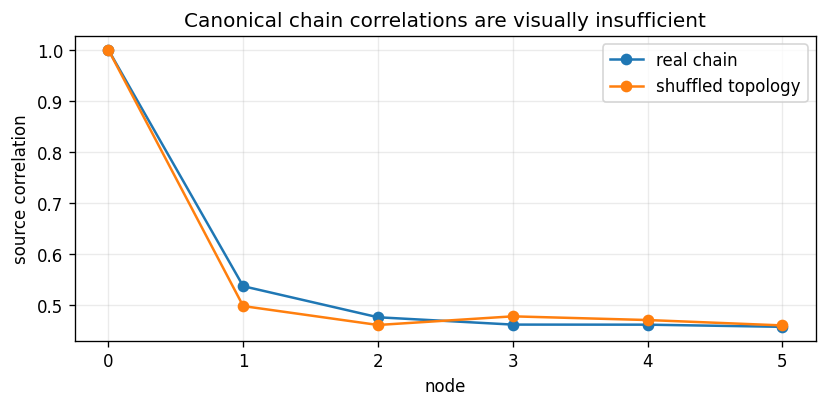

{'real': [1.0,
  0.5373421448225714,
  0.476502004766455,
  0.46214947215469776,
  0.4620092356556393,
  0.4578017794000673],
 'shuffled': [1.0,
  0.498432926495073,
  0.4613941972108385,
  0.47830574608798854,
  0.4710790008158445,
  0.46055232546783]}

In [5]:
corr_real = chain["real"]["mean_source_to_node_pulse_corr"]
corr_shuf = chain["shuffled_edges"]["mean_source_to_node_pulse_corr"]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(corr_real, marker="o", label="real chain")
ax.plot(corr_shuf, marker="o", label="shuffled topology")
ax.set(title="Canonical chain correlations are visually insufficient", xlabel="node", ylabel="source correlation")
ax.legend(); ax.grid(alpha=0.25); fig.tight_layout()
fig.savefig(FIG_DIR / "ch16-chain-control-artifact-audit.png", bbox_inches="tight")
plt.show()
{"real": corr_real, "shuffled": corr_shuf}


## Bounded conclusion

Causal transmission is supported: a bit changes receiver growth under checkpoint control. Sender-specific signalling is not supported because unrelated same-class and IPI-preserving controls do not separate in the required direction. Chain and board visuals remain insufficient.

## Provenance

Book chapter: `content/books/digital-life/16-before-there-are-messages/index.md`

Research scripts: `ch16_digital_crystal_signalling.py`, `v2`, `v3`, `v3_3`, `v3_4`

Canonical artifacts: `research/digital-life/ch16-reports/`, `research/digital-life/ch16-digital-crystal-signalling.sqlite3`

Execution mode: quick-recomputed + canonical-artifact-audit
